## Importing Libraries

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Data Preprocessing

### Training Image Preprocessing

In [2]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    verbose=True,
)

Found 734 files belonging to 18 classes.


## Validation Image Processing

In [3]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    verbose=True,
)

Found 8475 files belonging to 18 classes.


In [4]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 18), dtype=tf.float32, name=None))>

In [5]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[154.   137.   130.  ]
   [152.75 135.75 128.75]
   [151.5  134.5  127.5 ]
   ...
   [186.75 175.75 171.75]
   [182.75 171.75 167.75]
   [172.75 161.75 159.75]]

  [[154.5  137.5  130.5 ]
   [163.5  146.5  139.5 ]
   [158.5  141.5  134.5 ]
   ...
   [175.25 164.25 160.25]
   [178.   167.   163.  ]
   [179.5  168.5  166.5 ]]

  [[156.25 139.25 132.25]
   [162.75 145.75 138.75]
   [163.25 146.25 139.25]
   ...
   [180.25 169.25 165.25]
   [187.   176.   172.  ]
   [182.   171.   169.  ]]

  ...

  [[120.75  99.75  94.75]
   [116.25  95.25  90.25]
   [ 97.25  76.25  71.25]
   ...
   [111.25  90.25  85.25]
   [123.25 102.25  97.25]
   [141.25 120.25 115.25]]

  [[106.5   85.5   80.5 ]
   [107.25  86.25  81.25]
   [118.75  97.75  92.75]
   ...
   [124.5  103.5   98.5 ]
   [110.    89.    84.  ]
   [139.25 118.25 113.25]]

  [[107.5   86.5   81.5 ]
   [111.5   90.5   85.5 ]
   [133.   112.   107.  ]
   ...
   [109.25  88.25  83.25]
   [119.    98.    93.  ]
   [121.5  100.5   9

### To Avoid Overshooting
1. choose small learning rate default 0.001 we are taking 0.0001
2. there may be chance of underfitting, so increase no of neurons 
3. add more convolutional layer to extract more feature from images there may be possibility that model unable to capture relevant feature or model is confusing due to lack of feature so feed with more feature

## Building Model

In [6]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential


In [7]:
model = Sequential()

### Building Convolutional Layer

In [8]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))r

C:\Users\sanik\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [10]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [11]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [12]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [13]:
model.add(Dropout(0.25)) # to avoid overfitting

In [14]:
model.add(Flatten())

In [15]:
model.add(Dense(units=1500,activation='relu'))

In [16]:
model.add(Dropout(0.4))

### Output Layer

In [17]:
model.add(Dense(units=18,activation='softmax'))

### Compiling Model

In [18]:
model.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [64]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)                   │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 126, 126, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 63, 63, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 61, 61, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 30, 30, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 28, 28, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 14, 14, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_18 (Conv2D)                   │ (None, 6, 6, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1500)                │       3,073,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 1500)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 18)                  │          27,018 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,812,742 (29.80 MB)

 Trainable params: 7,812,742 (29.80 MB)

 Non-trainable params: 0 (0.00 B)

### Model Training

In [65]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 178s 8s/step - accuracy: 0.0560 - loss: 3.1021 - val_accuracy: 0.1266 - val_loss: 2.7866
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 164s 7s/step - accuracy: 0.1379 - loss: 2.7159 - val_accuracy: 0.2638 - val_loss: 2.3787
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 165s 7s/step - accuracy: 0.2760 - loss: 2.3272 - val_accuracy: 0.3410 - val_loss: 2.1378
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 321s 15s/step - accuracy: 0.3529 - loss: 2.1089 - val_accuracy: 0.3923 - val_loss: 1.9018
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 350s 16s/step - accuracy: 0.4811 - loss: 1.6533 - val_accuracy: 0.4616 - val_loss: 1.6983
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 383s 16s/step - accuracy: 0.5208 - loss: 1.5384 - val_accuracy: 0.5206 - val_loss: 1.5377
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 381s 16s/step - accuracy: 0.6286 - loss: 1.2254 - val_accuracy: 0.5622 - val_loss: 1.3614
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 353s 16s/step - accuracy: 0.6431 - loss: 1.0452 - val_accuracy: 0.578

## Model Evaluation

In [66]:
# Model evaluation on training set
train_loss,train_acc = model.evaluate(training_set)

23/23 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.8550 - loss: 0.4705


In [67]:
print(train_loss,train_acc)

0.5013225078582764 0.8405994772911072


In [68]:
# Model evaluation on validation set
val_loss,val_acc = model.evaluate(validation_set)


265/265 ━━━━━━━━━━━━━━━━━━━━ 279s 1s/step - accuracy: 0.6017 - loss: 1.2246


In [69]:
print(val_loss,val_acc)
model_json = model.to_json()

1.2160595655441284 0.614395260810852


In [70]:
model_json

'{"module": "keras", "class_name": "Sequential", "config": {"name": "sequential_1", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "layers": [{"module": "keras.layers", "class_name": "InputLayer", "config": {"batch_shape": [null, 128, 128, 3], "dtype": "float32", "sparse": false, "name": "input_layer_1"}, "registered_name": null}, {"module": "keras.layers", "class_name": "Conv2D", "config": {"name": "conv2d_10", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "filters": 32, "kernel_size": [3, 3], "strides": [1, 1], "padding": "same", "data_format": "channels_last", "dilation_rate": [1, 1], "groups": 1, "activation": "relu", "use_bias": true, "kernel_initializer": {"module": "keras.initializers", "class_name": "GlorotUniform", "config": {"seed": null}, "registered_name": null}, "bias_initializer": {"module": "keras.i

In [71]:
with open("model.json", "w") as json_file:
    json_file.write(model_json)

In [72]:
model.save_weights("model.weights.h5")
print("Saved model to disk")

Saved model to disk


In [73]:
from tensorflow.keras.models import Sequential, model_from_json
# load json and create model
json_file = open('model.json', 'r')
loaded_model_json = json_file.read()
json_file.close()
loaded_model = model_from_json(loaded_model_json)
# load weights into new model
loaded_model.load_weights("model.weights.h5")
print("Loaded model from disk")
 
# evaluate loaded model on test data
loaded_model.compile(loss='binary_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

Loaded model from disk


In [74]:
training_history.history

{'accuracy': [0.06539509445428848,
  0.1634877324104309,
  0.2724795639514923,
  0.35422343015670776,
  0.46594005823135376,
  0.5395095348358154,
  0.6280654072761536,
  0.6566757559776306,
  0.7152588367462158,
  0.7588555812835693],
 'loss': [2.965374231338501,
  2.632453203201294,
  2.309466600418091,
  2.045417547225952,
  1.6521990299224854,
  1.4758864641189575,
  1.17695152759552,
  1.0442649126052856,
  0.8619760870933533,
  0.7331347465515137],
 'val_accuracy': [0.12660767138004303,
  0.26383480429649353,
  0.3410029411315918,
  0.3923303782939911,
  0.4615929126739502,
  0.5205899477005005,
  0.5622419118881226,
  0.5782890915870667,
  0.6230088472366333,
  0.614395260810852],
 'val_loss': [2.7866456508636475,
  2.3787436485290527,
  2.1377787590026855,
  1.901774287223816,
  1.6983436346054077,
  1.5376629829406738,
  1.3613979816436768,
  1.3596879243850708,
  1.22034752368927,
  1.2160593271255493]}

## Accuracy Visualization

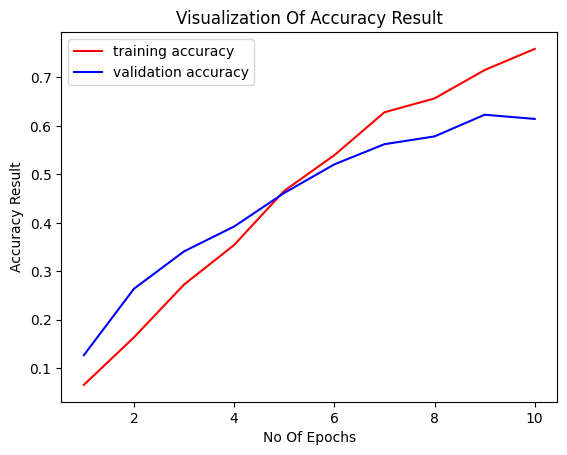

In [75]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='training accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='validation accuracy')
plt.xlabel("No Of Epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization Of Accuracy Result")
plt.legend()
plt.show()

### Some other metrics for model evaluation

In [76]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

In [77]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    verbose=True,
)

Found 8475 files belonging to 18 classes.


In [78]:
y_pred = model.predict(test_set)
y_pred,y_pred.shape

265/265 ━━━━━━━━━━━━━━━━━━━━ 283s 1s/step


(array([[8.35888386e-01, 2.61969715e-02, 2.33762228e-04, ...,
         1.51885004e-04, 2.84051312e-05, 1.41367980e-03],
        [5.68146646e-01, 3.80771197e-02, 3.41025647e-04, ...,
         6.35602279e-04, 3.01306602e-04, 6.98312977e-03],
        [9.18051481e-01, 3.34567204e-03, 5.97336111e-05, ...,
         3.78256264e-05, 8.45819068e-06, 1.26370043e-03],
        ...,
        [6.57603964e-02, 2.13565268e-02, 1.07679084e-01, ...,
         7.39227701e-03, 7.01938123e-02, 6.33800626e-01],
        [3.37240994e-02, 3.02142953e-03, 3.57223786e-02, ...,
         8.69114185e-04, 1.72445306e-03, 3.31772625e-01],
        [3.18826322e-04, 1.27326604e-03, 4.16653893e-06, ...,
         2.97707084e-05, 5.68582444e-03, 9.84652340e-01]], dtype=float32),
 (8475, 18))

In [79]:
predicted_categories = tf.argmax(y_pred,axis=1)
predicted_categories


<tf.Tensor: shape=(8475,), dtype=int64, numpy=array([ 0,  0,  0, ..., 17,  6, 17], dtype=int64)>

In [80]:
true_categories = tf.concat([y for x,y in test_set],axis=0)
true_categories

<tf.Tensor: shape=(8475, 18), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [81]:
y_true = tf.argmax(true_categories,axis=1)
y_true

<tf.Tensor: shape=(8475,), dtype=int64, numpy=array([ 0,  0,  0, ..., 17, 17, 17], dtype=int64)>

In [82]:
from sklearn.metrics import classification_report,confusion_matrix

In [83]:
print(classification_report(y_true,predicted_categories,target_names=class_name))

                                            precision    recall  f1-score   support

                        Apple___Apple_scab       0.55      0.59      0.57       504
                         Apple___Black_rot       0.39      0.65      0.49       497
                  Apple___Cedar_apple_rust       0.50      0.65      0.57       440
                           Apple___healthy       0.60      0.53      0.56       502
               Corn_(maize)___Common_rust_       0.79      0.75      0.77       477
       Corn_(maize)___Northern_Leaf_Blight       0.90      0.55      0.68       477
                    Corn_(maize)___healthy       0.56      1.00      0.72       465
                         Grape___Black_rot       0.62      0.95      0.75       472
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)       0.96      0.55      0.70       430
                           Grape___healthy       0.49      0.91      0.64       423
                     Potato___Early_blight       0.92      0.64      0.76  

In [84]:
cm = confusion_matrix(y_true,predicted_categories)
cm.shape

(18, 18)

### Confusion Matrix Visualization 

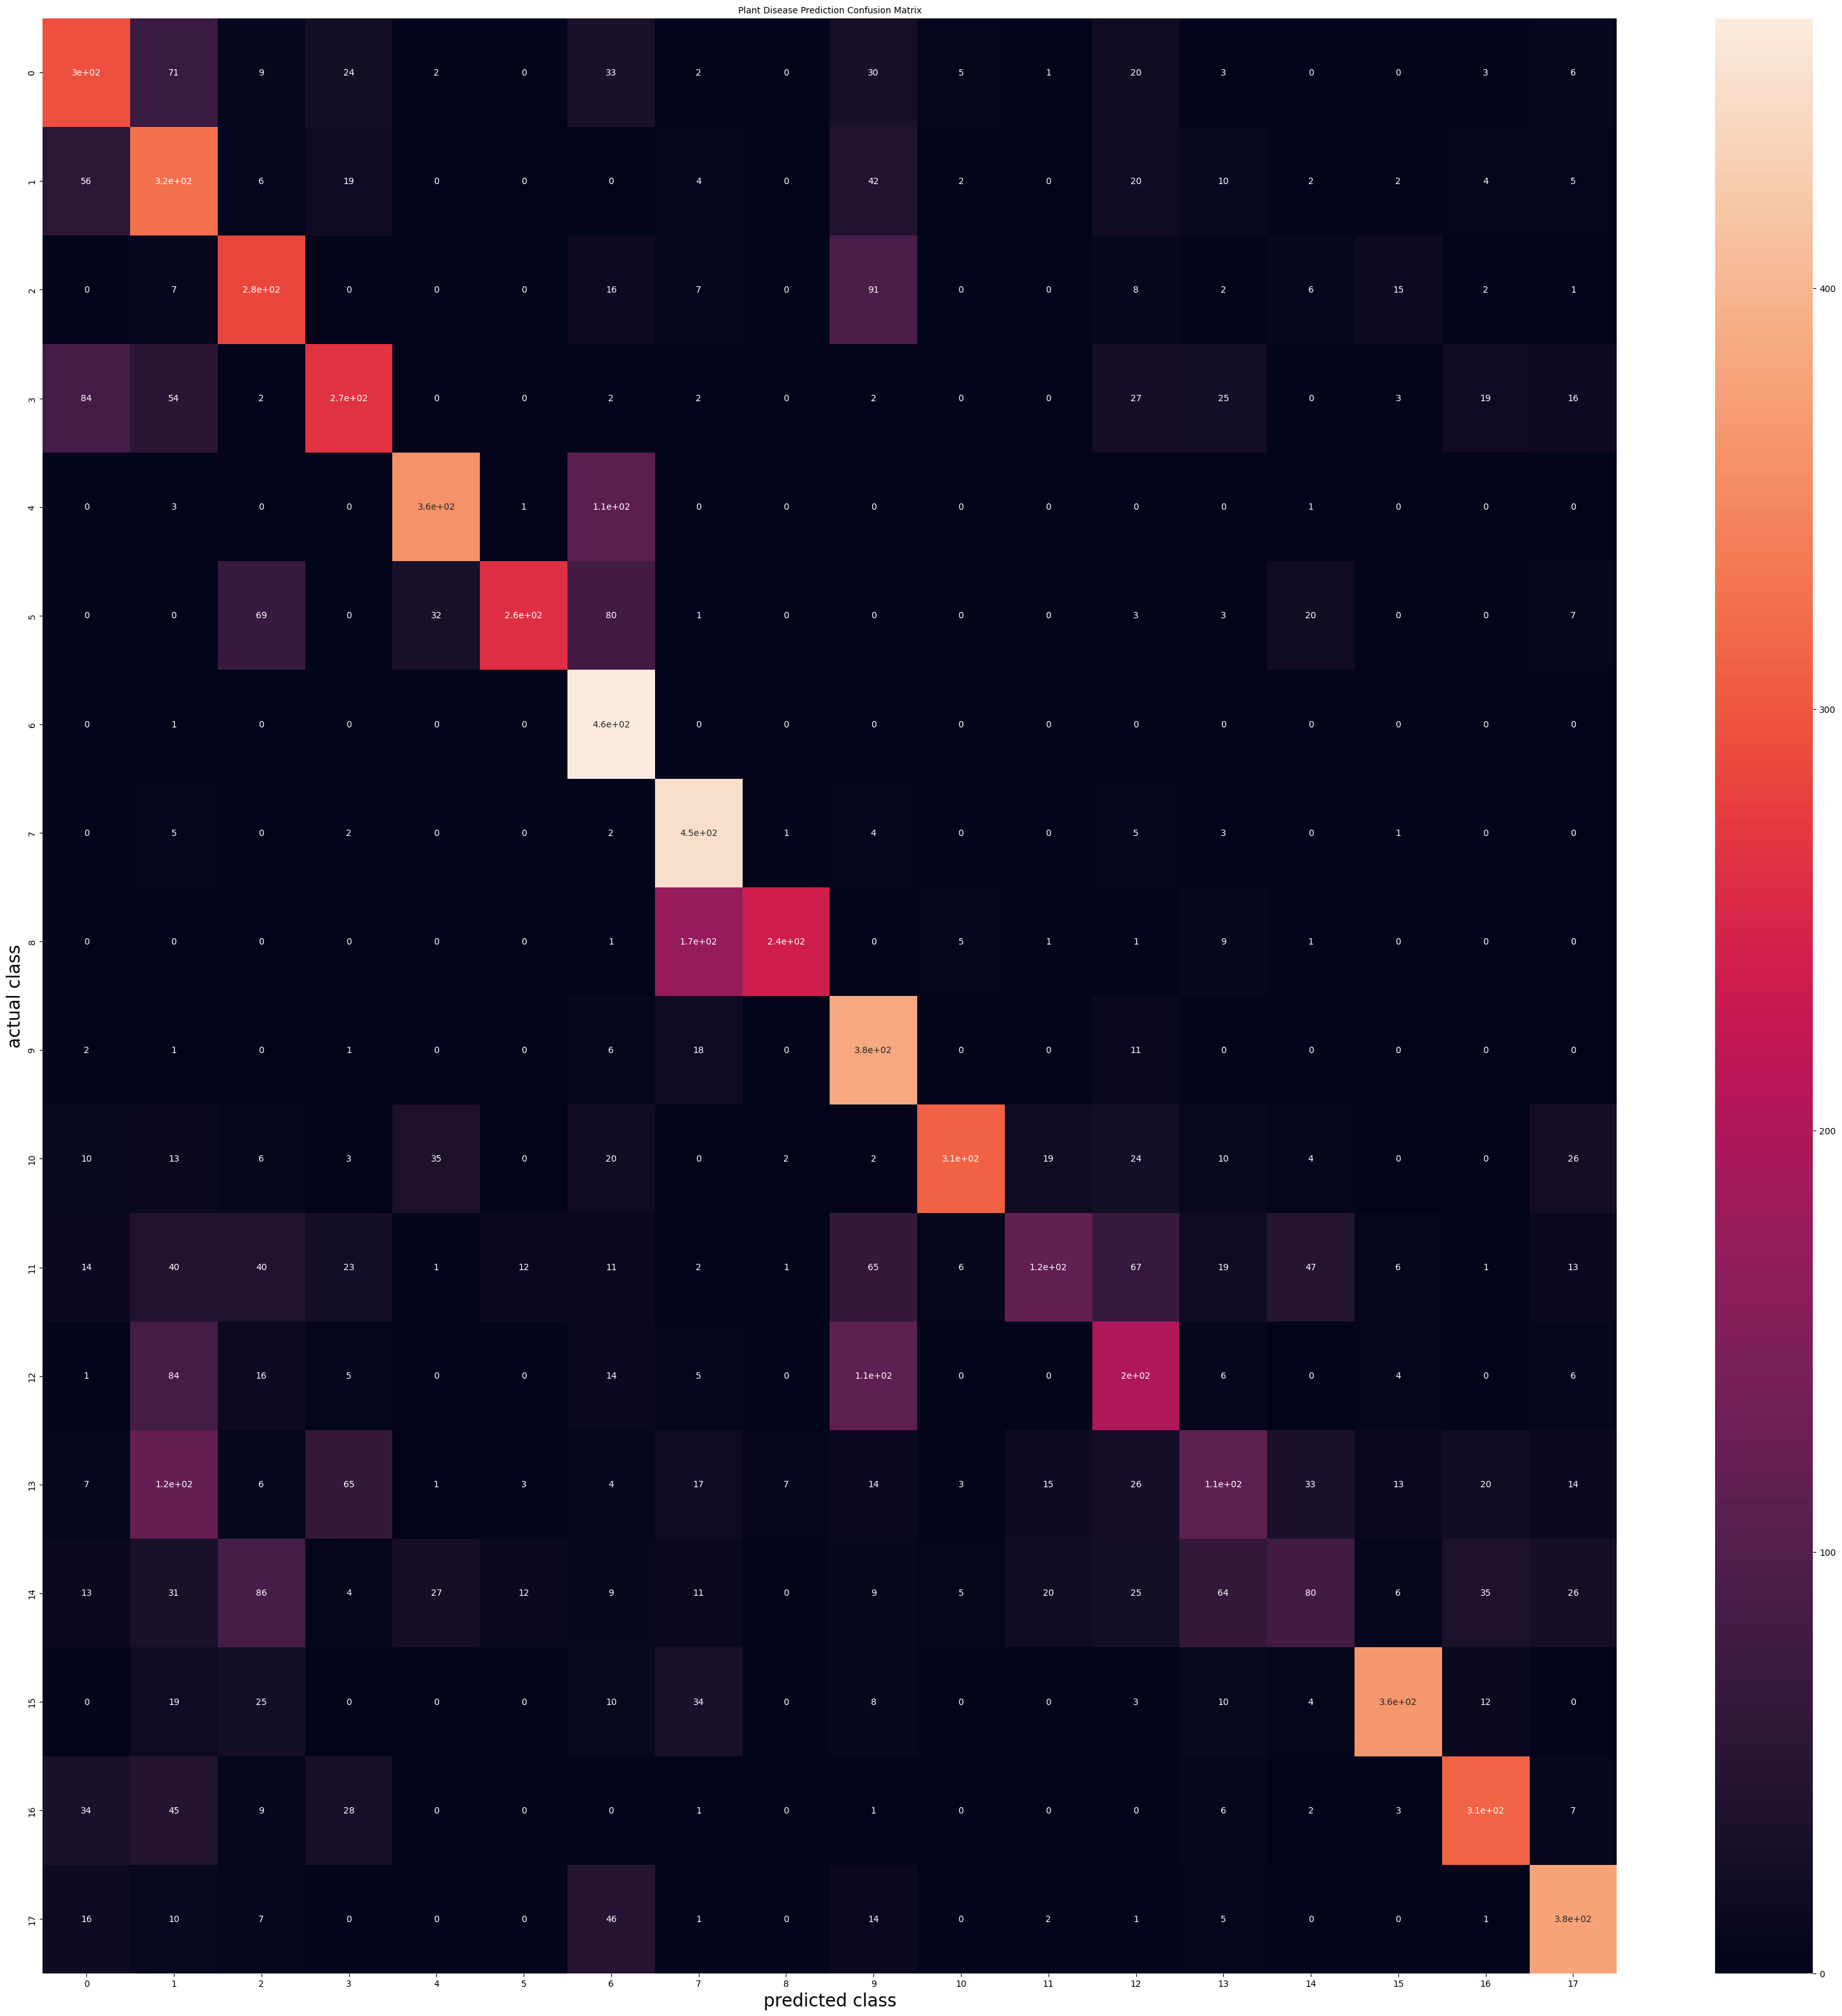

In [85]:
plt.figure(figsize=(40,40))
sns.heatmap(cm,annot=True)
plt.xlabel("predicted class",fontsize=20)
plt.ylabel("actual class",fontsize=20)
plt.title("Plant Disease Prediction Confusion Matrix",fontsize=10)
plt.show()